<a href="https://colab.research.google.com/github/cybersparsh/Mnist/blob/main/Mnist_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
y_train = to_categorical(y_train, num_classes=10)

In [ ]:
y_test = to_categorical(y_test, num_classes=10)

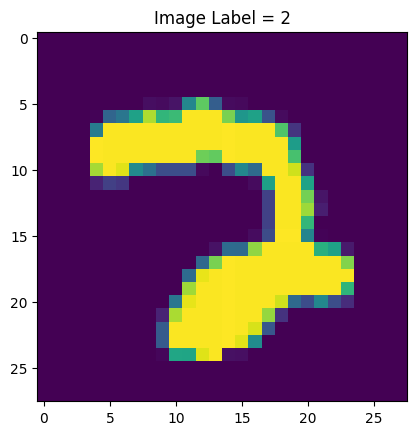

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[120])
plt.title(f"Image Label = {y_train[120]}")
plt.show()

In [ ]:
model = Sequential([
    Flatten(input_shape = (28,28)),             # Input layer = 784 neurons
    Dense(5, activation = 'relu'),              # Hidden Layer = 5 neurons
    Dense(10, activation = 'softmax')           # Output Laayer = 10 neurons
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           3,925 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │              60 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs = 5,batch_size = 32,verbose = 2)

Epoch 1/5
1875/1875 - 4s - 2ms/step - accuracy: 0.2799 - loss: 2.1762
Epoch 2/5
1875/1875 - 3s - 2ms/step - accuracy: 0.3881 - loss: 1.8075
Epoch 3/5
1875/1875 - 6s - 3ms/step - accuracy: 0.4523 - loss: 1.5422
Epoch 4/5
1875/1875 - 4s - 2ms/step - accuracy: 0.4873 - loss: 1.3965
Epoch 5/5
1875/1875 - 6s - 3ms/step - accuracy: 0.5097 - loss: 1.3131


In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5313 - loss: 1.2945


[1.2689229249954224, 0.5245000123977661]

In [ ]:
model.save('mnist.h5')

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Flatten, concatenate

In [ ]:
input_layer = Input(shape=(28,28))
flatten = Flatten(input_shape = (28,28))(input_layer)
hidden1 = Dense(128, activation='relu')(flatten)
hidden2 = Dense(256, activation='relu')(flatten)
hidden11 = Dense(64, activation='relu')(hidden1)
merge = concatenate([hidden11,hidden2])
output_layer = Dense(10, activation='softmax')(merge)

In [ ]:
model = Model(inputs = input_layer, outputs = output_layer)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 28, 28)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 784)            │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │        100,480 │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 64)             │          8,256 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 256)            │        200,960 │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 320)            │              0 │ dense_4[0][0],         │
│                           │                        │                │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 10)             │          3,210 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 312,906 (1.19 MB)

 Trainable params: 312,906 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

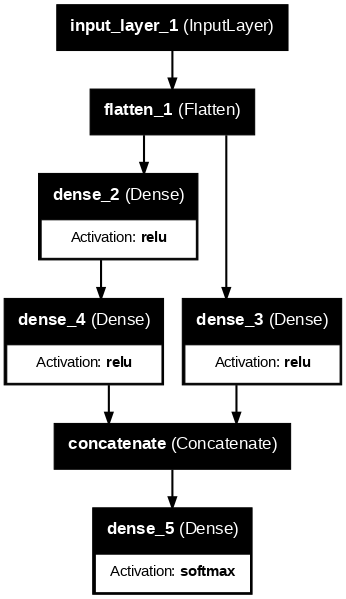

In [ ]:
from keras.utils import plot_model

plot_model(model, show_layer_names=True, dpi = 75, show_layer_activations=True)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs = 5,batch_size = 32,verbose = 2)

Epoch 1/5
1875/1875 - 10s - 6ms/step - accuracy: 0.7825 - loss: 0.7690
Epoch 2/5
1875/1875 - 9s - 5ms/step - accuracy: 0.9003 - loss: 0.3530
Epoch 3/5
1875/1875 - 8s - 4ms/step - accuracy: 0.9139 - loss: 0.3014
Epoch 4/5
1875/1875 - 11s - 6ms/step - accuracy: 0.9213 - loss: 0.2738
Epoch 5/5
1875/1875 - 11s - 6ms/step - accuracy: 0.9276 - loss: 0.2497


In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9224 - loss: 0.2684


[0.23749704658985138, 0.9307000041007996]

In [ ]:
model.save('mnist.h5')